# Loss Functions, Class Weighting and Calibration
## A twelve-model comparison on the SIVE vegetation-line dataset

Every model below was trained with the original author's code
(`sentinel2-vegetation-line`) and the SIVE dataset. The only thing changed
is which loss the training sweep was asked for. Nothing in this notebook is
simulated or estimated — every number is computed from 300 cached
probability maps (12 models × 25 test scenes).

In [1]:
# This notebook is generated from model_comparison.py (jupytext 'percent'
# format). To regenerate and re-execute it:
#     jupytext --to notebook model_comparison.py
#     jupyter nbconvert --execute --inplace model_comparison.ipynb
# Edit the .py, not the .ipynb.

import os
import sys

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.join("..", "src"))

# The figures below are *built* by this notebook, not loaded from disk:
# figures_paper.py holds the plotting code, each call renders inline here and
# writes the vector PDF the paper uses, so the two can never drift apart.
import models as MD
import figures_paper as FP

%matplotlib inline
FP._setup()

RESULTS = os.path.join("..", "results")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

per_model = pd.read_csv(os.path.join(RESULTS, "exp1_per_model.csv"))
threshold = pd.read_csv(os.path.join(RESULTS, "exp2_threshold.csv"))
ranking = pd.read_csv(os.path.join(RESULTS, "exp5_ranking.csv"))
one_way = pd.read_csv(os.path.join(RESULTS, "exp1_one_way.csv"))

LOSS_ORDER = ["BCE", "DICE", "wBCE"]
CONFIG_ORDER = ["trainable_guided", "frozen_guided",
                "trainable_unguided", "frozen_unguided"]

print(f"{per_model.model.nunique()} models "
      f"× {per_model.image.nunique()} test scenes "
      f"= {len(per_model)} model-scene evaluations")

12 models × 25 test scenes = 300 model-scene evaluations


---
## 1. The twelve models

The comparison is a **full factorial design**: three binary or ternary
choices, crossed completely, giving 2 × 2 × 3 = 12 models. A full factorial
matters because it lets each factor be assessed while the other two are held
fixed — with an incomplete design, any average taken across a factor is
contaminated by which cells happen to exist.

In [2]:
design = (per_model.groupby(["config", "loss"]).size()
          .unstack().notna()
          .reindex(index=CONFIG_ORDER, columns=LOSS_ORDER)
          .replace({True: "trained", False: "—"}))
design.index = design.index.str.replace("_", " + ")
design.columns.name = "loss function"
design.index.name = "backbone + guidance"
design

loss function,BCE,DICE,wBCE
backbone + guidance,,,
trainable + guided,trained,trained,trained
frozen + guided,trained,trained,trained
trainable + unguided,trained,trained,trained
frozen + unguided,trained,trained,trained


### Provenance of these models

The original author released **the dataset and the code, but not the trained
weights**, so all twelve were trained here:

| batch | models | why |
|---|---|---|
| 1 | 8 — the author's own design (`{frozen, trainable}` × `{guided, unguided}` × `{wBCE, DICE}`) | reproduction |
| 2 | 2 — `guided` × `BCE` | the missing control |
| 3 | 2 — `unguided` × `BCE` | completing the factorial design |

The BCE column did not exist in the original work. The published training
sweep runs `for loss in ["wBCE", "DICE"]`, so unweighted cross-entropy —
though implemented in the same file — was never trained. That omission is
what made the original comparison unable to separate *loss family* from
*class weighting*, since wBCE differs from DICE in both at once.

All twelve share the same 70/30 training and validation split (fixed by seed
42), the same four-rate learning-rate sweep and the same early stopping. The
seed fixes only the split: the initial weights of the new layers and the batch
order are not seeded, and each model was trained once, so the variation between
runs is not measured. Only the loss differs between the models, which is what
makes the comparison controlled.

---
## 2. What the three factors are

### 2.1 `trainable` vs `frozen` — whether the backbone adapts

The network is a Holistically-nested Edge Detection (HED) architecture on a
ResNet-50 backbone pretrained on **BigEarthNet**, a large Sentinel-2
land-cover corpus. Transfer learning then offers two options:

- **frozen** — backbone weights are locked; only the detection head trains.
  Fewer trainable parameters, less overfitting risk, but the features cannot
  specialise to this task.
- **trainable** — the whole network updates. Features adapt, at the cost of
  more capacity to overfit.

The original author framed this as a diagnostic: *"If the features are
relevant, then we expect the frozen and unfrozen versions of this backbone
to provide similar performance."* They do not, which says the BigEarthNet
features need adaptation for edge detection.

### 2.2 `guided` vs `unguided` — a hand-drawn prior as a fifth input band

Input imagery has four bands: red, green, blue, near-infrared. A **guided**
model receives a fifth channel, the *guidance band*.

That band is **drawn by hand, once per beach**, marking roughly where the
coast lies. Three properties were verified directly from the data:

1. It is **static** — every date at a site shares one identical band
   (Rossnowlagh's 16 scenes all carry exactly 4,291 positive pixels).
2. It covers about **1% of the scene**.
3. **Every ground-truth line pixel falls inside it** — mean distance 0.0 m.

So a guided model is not searching the scene for a coast; it is thinning a
human-drawn corridor that already contains the answer. This also means the
framework is **not fully automatic at a new site**: someone must draw the
band first.

### 2.3 The three loss functions

The task is edge detection, not segmentation: the network outputs one
probability per pixel that *this pixel lies on the vegetation line*. The
ground truth is a one-pixel-wide curve, so **positive pixels are ~0.6% of a
training crop**. Every loss below is a different answer to that imbalance.

**BCE — binary cross-entropy.** The standard per-pixel classification loss.
Critically it is a **proper scoring rule**: it is minimised when the
predicted probability equals the true probability, which is exactly why a
BCE-trained model is well calibrated. Its weakness is that predicting "no
edge" everywhere is already 99.4% correct, so it outputs low probabilities
and a fixed 0.5 cut detects almost nothing.

**wBCE — weighted binary cross-entropy.** BCE with the positive class
multiplied by **166** (the reciprocal of the 0.6% prevalence). This forces
the model to attend to edges, but it **removes the proper scoring rule property**. For
weight $w$ and true probability $p$, the loss-minimising output is

$$q^{*} = \frac{w \, p}{1 - p + w \, p}$$

which for $w = 166$ inflates a true 0.6% to a predicted 0.50, and a true 0.5
to a predicted 0.994. The overconfidence is not an artefact of training —
it is the optimum the loss defines.

**DICE.** Optimises region overlap, $1 - 2|A \cap B| / (|A| + |B|)$. The
overlap ratio is normalised by the sizes of prediction and target, so class
frequency never enters and no weight is needed. It is not a proper scoring
rule either — it saturates towards 0 and 1 — but it introduces no systematic
one-way bias.

---
## 3. The evaluation metrics, and why each one

| metric | what it asks | why it is needed |
|---|---|---|
| **FOM @ 0.5** | how good is detection at the default cut? | what a user gets out of the box |
| **FOM best** | how good could it be at its own best cut? | separates "cannot find the line" from "0.5 is the wrong cut" |
| **Operating window** | over what fraction of thresholds does FOM stay within 0.02 of its best? | tuning a threshold needs labels from the deployment site — the one thing nobody has |
| **ECE** | mean gap between stated confidence and observed frequency | whether the probabilities mean anything |
| **Signed CE** | the same gap, keeping its sign | direction: positive is overconfident |
| **Transfer drop** | loss in FOM from seen to unseen coastline | whether any of the above survives a new beach |

Two choices deserve justification.

**Why FOM rather than IoU or F1.** A line placed one pixel off is
operationally fine but scores zero intersection under IoU. Pratt's Figure of
Merit is distance-tolerant,
$\mathrm{FOM} = \frac{1}{\max(N_{\text{pred}}, N_{\text{true}})}\sum_i (1 + \alpha d_i^2)^{-1}$,
and is the metric the original work headlines, so results stay comparable.

**Why calibration is measured only near the line.** Positive pixels are
~0.05% of a full scene. A whole-image calibration score is dominated by
trivially-correct background and makes every model look well calibrated, so
all calibration numbers here are restricted to pixels within 10 px of the
true line — the region where confidence has consequences.

---
## 4. Detection and calibration, per model

Averaged over scenes. `seen` is four beaches also present in training;
`unseen` is Rossnowlagh, held out entirely.

In [3]:
tbl = (per_model.groupby(["config", "loss", "split"])[["fom", "ece", "sce"]]
       .mean().unstack("split"))
tbl.columns = [f"{m}_{s}" for m, s in tbl.columns]
tbl = tbl[["fom_seen", "fom_unseen", "ece_seen", "ece_unseen",
           "sce_seen", "sce_unseen"]]
tbl = tbl.reindex(pd.MultiIndex.from_product([CONFIG_ORDER, LOSS_ORDER],
                                             names=["config", "loss"]))
tbl.columns = pd.MultiIndex.from_tuples(
    [("FOM", "seen"), ("FOM", "unseen"),
     ("ECE", "seen"), ("ECE", "unseen"),
     ("Signed CE", "seen"), ("Signed CE", "unseen")])
tbl.round(4)

FOM             ECE         Signed CE        
                           seen  unseen    seen  unseen      seen  unseen
config             loss                                                  
trainable_guided   BCE   0.8575  0.6832  0.0059  0.0124    0.0018 -0.0045
                   DICE  0.9478  0.9276  0.0346  0.0356    0.0185  0.0073
                   wBCE  0.8902  0.9010  0.1123  0.0872    0.1123  0.0861
frozen_guided      BCE   0.5009  0.3431  0.0078  0.0130   -0.0019 -0.0101
                   DICE  0.9355  0.8841  0.0364  0.0375    0.0091  0.0024
                   wBCE  0.8066  0.7970  0.1792  0.1800    0.1792  0.1800
trainable_unguided BCE   0.6773  0.2143  0.0073  0.0292   -0.0013 -0.0268
                   DICE  0.6999  0.4728  0.0351  0.0385    0.0163 -0.0161
                   wBCE  0.5842  0.4788  0.1072  0.0617    0.1053  0.0345
frozen_unguided    BCE   0.5201  0.1006  0.0125  0.0262   -0.0039 -0.0255
                   DICE  0.5699  0.3271  0.0424  0.0388    0.0128 -0.0204
                   wBCE  0.1969  0.2226  0.2052  0.1524    0.2052  0.1501

**Read the `Signed CE` columns down each configuration block.** Holding the
backbone and guidance fixed and changing only the loss, the weighted variant
is an order of magnitude more overconfident than either unweighted one, in
all four configurations.

That is the paper's central result, and it reads better as a picture than as
a column of numbers — three bands that never overlap, in every configuration:

  wrote paper_fig1_separation.pdf / .png


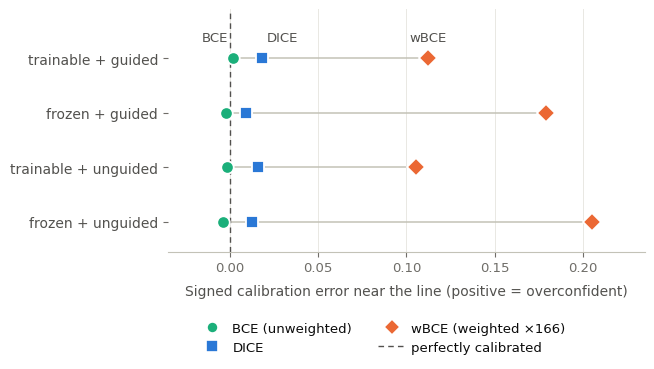

In [4]:
_ = FP.fig_separation(per_model)

> **Figure 1.** Signed calibration error near the detected line, for all
> twelve models, grouped by configuration. Positive is overconfident. Within
> every configuration the two unweighted losses sit against the zero rule
> while the weighted variant sits an order of magnitude away, and the three
> bands never overlap.

In [5]:
sep = (per_model[per_model.split == "seen"]
       .groupby(["config", "loss"]).sce.mean().unstack()[LOSS_ORDER])
sep["BCE vs wBCE gap"] = sep["wBCE"] - sep["BCE"]
sep = sep.reindex(CONFIG_ORDER).sort_values("BCE vs wBCE gap", ascending=False)
sep.round(4)

loss,BCE,DICE,wBCE,BCE vs wBCE gap
config,,,,
frozen_unguided,-0.0039,0.0128,0.2052,0.2091
frozen_guided,-0.0019,0.0091,0.1792,0.1810
trainable_guided,0.0018,0.0185,0.1123,0.1105
trainable_unguided,-0.0013,0.0163,0.1053,0.1066


The largest single contrast, 0.209, is in `frozen_unguided` — the *hardest*
configuration, where detection accuracy is worst. Calibration and detection
quality are independent axes, and the weighting effect is strongest exactly
where the task is hardest.

### Is the weighted error systematic or just noisy?

ECE takes the absolute value of each bin's error before averaging; signed CE
keeps the sign. The two can only coincide if **every probability bin errs in
the same direction**. Their ratio is therefore a one-number test for
systematic bias.

In [6]:
ow = one_way.set_index("loss").reindex(LOSS_ORDER)[["ece", "abs_sce", "ratio"]]
ow.columns = ["ECE", "|Signed CE|", "ratio → 1 means one-way"]
ow.round(4)

,ECE,|Signed CE|,ratio → 1 means one-way
loss,,,
BCE,0.0159,0.0122,0.6390
DICE,0.0374,0.0139,0.3702
wBCE,0.1314,0.1264,0.9149


wBCE sits at 0.91: essentially every bin is wrong in the same direction —
a systematic bias. The unweighted losses sit at 0.37–0.64, where errors
partly cancel, which is what calibrated-plus-noise looks like.

### The mechanism, and a prediction the loss makes on its own

Because weighted BCE has a closed-form optimum, it predicts the *whole
reliability curve* with no fitted parameters. Inverting
$q^{*} = wp/(1-p+wp)$ gives the frequency with which a model reporting $q$
should actually be right:

$$p(q) = \frac{q}{w + q - qw}$$

The dashed line below is that prediction. It is not fitted to anything.

  wrote paper_fig2_reliability.pdf / .png


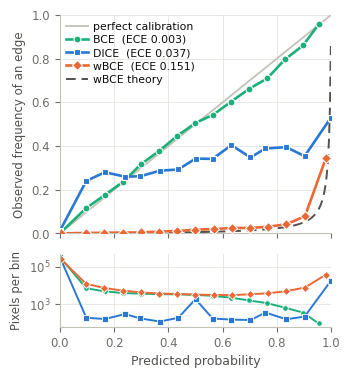

In [7]:
IMAGES = MD.available_images()
_ = FP.fig_reliability(IMAGES)

> **Figure 2.** Reliability of the three losses on seen locations, pooled
> over all four configurations. The dashed curve is the optimum that the
> weighted loss defines, with no free parameters. The lower panel gives the
> bin populations.

Three things this figure says that the tables cannot.

**The weighted curve follows its predicted optimum.** The residual between
prediction and measurement is 0.014, against a total calibration error of
0.151 — so roughly nine tenths of the miscalibration is explained by the
loss function alone, before any appeal to optimisation or capacity. The
model is not failing to learn; it is learning exactly what it was asked to.

**Unweighted BCE is genuinely calibrated**, tracking the diagonal from 0.1
to 0.95 — the behaviour a proper scoring rule guarantees.

**DICE is not calibrated in the same sense**, and the lower panel is why.
Its curve wanders (overconfident above 0.6, underconfident below 0.3) and
its bin counts collapse by two orders of magnitude in the middle of the
range: DICE barely emits intermediate probabilities at all. Its small
*signed* error reflects errors that cancel across a near-binary output, not
probabilities that can be believed individually. Its ECE, 0.037, is more
than ten times that of BCE (0.003).

This distinction matters for how the recommendation should be worded. The
accurate three-way statement is: **wBCE is systematically biased, BCE is
genuinely calibrated, and DICE is neither biased nor truly probabilistic.**

---
## 5. Effect of the class weight on accuracy and threshold selection

An unweighted model outputs low probabilities everywhere, so it looks
useless at a 0.5 cut. Sweeping the threshold separates inability from a
misplaced cut.

In [8]:
th = (threshold.groupby(["config", "loss"])
      [["fom_at_05", "fom_best", "best_threshold", "window_frac"]]
      .mean()
      .reindex(pd.MultiIndex.from_product([CONFIG_ORDER, LOSS_ORDER],
                                          names=["config", "loss"])))
th.columns = ["FOM @ 0.5", "FOM best", "best threshold", "operating window"]
th.round(3)

FOM @ 0.5  FOM best  best threshold  operating window
config             loss                                                       
trainable_guided   BCE       0.770     0.950            0.33             0.296
                   DICE      0.938     0.946            0.50             0.776
                   wBCE      0.896     0.938            0.97             0.143
frozen_guided      BCE       0.422     0.941            0.24             0.153
                   DICE      0.910     0.922            0.03             0.663
                   wBCE      0.802     0.916            0.97             0.041
trainable_unguided BCE       0.446     0.617            0.22             0.214
                   DICE      0.586     0.593            0.39             0.755
                   wBCE      0.532     0.609            0.97             0.082
frozen_unguided    BCE       0.310     0.547            0.21             0.112
                   DICE      0.448     0.464            0.50             0.510
                   wBCE      0.210     0.484            0.97             0.041

In [9]:
by_loss = (threshold.groupby("loss")
           .agg(**{"FOM best": ("fom_best", "mean"),
                   "optimum (min)": ("best_threshold", "min"),
                   "optimum (max)": ("best_threshold", "max"),
                   "operating window": ("window_frac", "mean")})
           .reindex(LOSS_ORDER))
by_loss.round(3)

,FOM best,optimum (min),optimum (max),operating window
loss,,,,
BCE,0.764,0.06,0.42,0.194
DICE,0.731,0.02,0.98,0.676
wBCE,0.737,0.96,0.98,0.077


Plotted on the threshold axis, the question becomes one a reader can answer
at a glance: **does the default cut fall inside the usable range?**

  wrote paper_fig3_threshold.pdf / .png


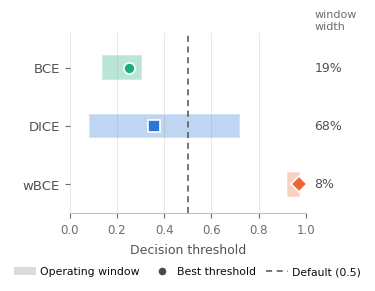

In [10]:
_ = FP.fig_threshold(threshold)

> **Figure 3.** The operating window of each loss — the span of decision
> thresholds over which FOM stays within 0.02 of that loss's own best — with
> the marker at its optimum. Averaged over all four configurations.

Three things follow.

1. **At its own optimum, unweighted BCE is the most accurate loss.** The
   weight does not improve detection accuracy.
2. **0.5 is not the right cut for wBCE either.** Its window sits at the top
   of the range and does not contain the default at all. The weight moves
   where the model fails; it does not stop it failing.
3. **wBCE has the narrowest window of the three** (8%). DICE's is over eight
   times wider and is the only one that straddles 0.5, so DICE can be
   shipped at any sensible threshold while the others must be tuned per
   site — and tuning needs labels from the deployment site.

---
## 6. Multi-factor ranking

Five criteria, each able on its own to make a model unusable. All are
min-max normalised across the twelve models and averaged with equal weight.
Equal weighting is a **choice, not a fact** — per-criterion ranks are shown
alongside so the table remains usable under a different weighting.

In [11]:
rank = ranking.sort_values("rank").copy()
rank["configuration"] = rank.config.str.replace("_", " + ")
out = rank[["rank", "configuration", "loss", "accuracy", "ceiling",
            "robustness", "calibration", "transfer", "composite"]].copy()
out["calibration"] = -out["calibration"]      # display as |error|
out["transfer"] = -out["transfer"]            # display as FOM drop
out.columns = ["rank", "configuration", "loss", "FOM @ 0.5", "FOM best",
               "window", "|cal. error|", "FOM drop", "composite"]
out.set_index("rank").round(4)

,configuration,loss,FOM @ 0.5,FOM best,window,|cal. error|,FOM drop,composite
rank,,,,,,,,
1,trainable + guided,DICE,0.9377,0.9460,0.7755,0.0129,0.0115,0.9808
2,frozen + guided,DICE,0.9098,0.9216,0.6633,0.0058,0.0438,0.9141
3,trainable + guided,BCE,0.7703,0.9503,0.2959,0.0031,0.0130,0.8159
4,trainable + guided,wBCE,0.8956,0.9383,0.1429,0.0992,0.0039,0.7023
5,frozen + guided,BCE,0.4220,0.9410,0.1531,0.0060,0.0096,0.6771
6,trainable + unguided,DICE,0.5864,0.5925,0.7551,0.0162,0.2246,0.5540
7,frozen + guided,wBCE,0.8018,0.9157,0.0408,0.1796,0.0169,0.5378
8,frozen + unguided,DICE,0.4485,0.4640,0.5102,0.0166,0.2465,0.3781
9,trainable + unguided,BCE,0.4458,0.6170,0.2143,0.0140,0.2334,0.3734


For `|cal. error|` and `FOM drop` **smaller is better**; both were negated
before scoring so the composite is consistently higher-is-better.

As a grid of magnitudes this is a heatmap, which carries the same numbers in
a quarter of the page and makes the row-wise pattern legible — the two DICE
rows at the top are dark almost everywhere, whereas the models below them
are dark in some criteria and pale in others:

  wrote paper_fig4_ranking.pdf / .png


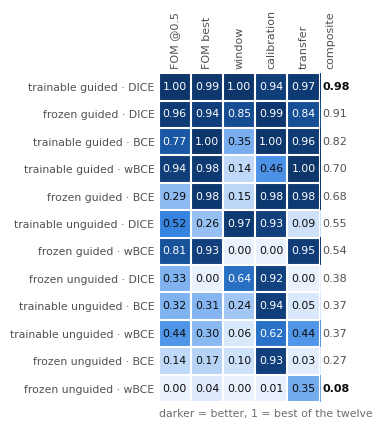

In [12]:
_ = FP.fig_ranking(ranking)

> **Figure 4.** All twelve models against all five criteria, min-max
> normalised so 1 is the best of the twelve on that criterion. Cell values
> are printed so the figure also serves as the table. Rows are ordered by
> the equal-weighted composite, shown at the right.

The pattern worth noticing is not who wins but **how they win**. The top two
rows are uniformly strong. Rows three to five each contain a 1.00 — they are
best-in-class at something — yet sit mid-table because each also contains a
value near zero. A model is only as deployable as its weakest criterion.

In [13]:
winners = pd.DataFrame({
    "best": [rank.loc[rank[c].idxmax(), "config"] + " / "
             + rank.loc[rank[c].idxmax(), "loss"]
             for c in ["accuracy", "ceiling", "robustness",
                       "calibration", "transfer"]],
    "worst": [rank.loc[rank[c].idxmin(), "config"] + " / "
              + rank.loc[rank[c].idxmin(), "loss"]
              for c in ["accuracy", "ceiling", "robustness",
                        "calibration", "transfer"]],
}, index=["accuracy", "ceiling", "robustness", "calibration", "transfer"])
winners.index.name = "criterion"
winners

,best,worst
criterion,,
accuracy,trainable_guided / DICE,frozen_unguided / wBCE
ceiling,trainable_guided / BCE,frozen_unguided / DICE
robustness,trainable_guided / DICE,frozen_guided / wBCE
calibration,trainable_guided / BCE,frozen_guided / wBCE
transfer,trainable_guided / wBCE,frozen_unguided / DICE


### Marginal effect of each factor

In [14]:
marg = pd.concat([
    rank.groupby("loss").composite.mean().rename("mean composite")
        .to_frame().assign(factor="loss function"),
    rank.assign(k=rank.config.str.split("_").str[0])
        .groupby("k").composite.mean().rename("mean composite")
        .to_frame().assign(factor="backbone"),
    rank.groupby(rank.guided.map({True: "guided", False: "unguided"}))
        .composite.mean().rename("mean composite")
        .to_frame().assign(factor="guidance band"),
])
marg.index.name = "level"
marg = marg.reset_index().set_index(["factor", "level"]).sort_index()
marg.round(3)

mean composite
factor        level                    
backbone      frozen              0.477
              trainable           0.633
guidance band guided              0.771
              unguided            0.339
loss function BCE                 0.535
              DICE                0.707
              wBCE                0.423

The **spread** of each factor — how much separates its best level from its
worst — is the fair way to compare factors against one another:

In [15]:
(marg.groupby("factor")["mean composite"]
     .agg(lambda s: s.max() - s.min())
     .rename("spread of mean composite")
     .sort_values(ascending=False)
     .round(3).to_frame())

,spread of mean composite
factor,
guidance band,0.433
loss function,0.283
backbone,0.156


---
## 7. Best and worst

In [16]:
best, worst = rank.iloc[0], rank.iloc[-1]
pd.DataFrame({
    "BEST": [f"{best.config} / {best.loss}", round(best.composite, 3),
             round(best.accuracy, 3), round(best.ceiling, 3),
             round(best.robustness, 3), round(-best.calibration, 4)],
    "WORST": [f"{worst.config} / {worst.loss}", round(worst.composite, 3),
              round(worst.accuracy, 3), round(worst.ceiling, 3),
              round(worst.robustness, 3), round(-worst.calibration, 4)],
}, index=["model", "composite", "FOM @ 0.5", "FOM best",
          "operating window", "|calibration error|"])

,BEST,WORST
model,trainable_guided / DICE,frozen_unguided / wBCE
composite,0.981,0.081
FOM @ 0.5,0.938,0.21
FOM best,0.946,0.484
operating window,0.776,0.041
|calibration error|,0.0129,0.1776


**Best — `trainable_guided` / DICE.** It wins no criterion by a landslide
but has no weakness: strong out of the box, strong at its ceiling, by far
the widest operating window, and calibration within 0.013.

**Worst — `frozen_unguided` / wBCE.** Lowest accuracy, second-worst
calibration, and an operating window of 0.041. A factor of twelve separates
it from the best.

---
## 8. Insights

### Three losses are three distinct failure modes

| | are the probabilities trustworthy? | usable out of the box? | sensitive to the threshold? |
|---|---|---|---|
| **BCE** | yes — tracks the diagonal, ECE 0.003 | no — collapses at 0.5 | very |
| **wBCE** | no — systematically inflated, ECE 0.151 | marginally | very — optimum near 0.96 |
| **DICE** | not really — near-binary, ECE 0.037 | yes | **no** |

Figure 2 forces a more careful statement than "DICE is well calibrated."
DICE's *signed* error is small because its errors cancel, not because its
probabilities are right; it hardly uses the middle of the probability range
at all. So the three losses fail in three different ways: wBCE is
**biased**, DICE is **uninformative** between 0 and 1, and BCE is neither
but cannot be deployed at the default threshold.

DICE is not the strongest on any single axis. It is the only one with no
*disqualifying* weakness, and that — not a marginal FOM difference — is the
reason to recommend it. If the probabilities themselves are needed
downstream (for example to propagate positional uncertainty into an erosion
rate), DICE is not sufficient and BCE with a tuned threshold, or a
recalibrated model, is the better basis.

### The weight acts as a threshold shift built into the model, at the cost of calibration

The weight does not improve accuracy: unweighted BCE is the most accurate loss
at its own optimum in seven of eight comparisons. Nor does it provide a usable
default threshold: the operating window of wBCE is the narrowest of the three
and does not contain 0.5. The weight only moves the useful threshold range
away from the default cut, and the cost is paid in calibration.

### Capability and usability are different things

The trainable, guided BCE model wins two criteria outright, the best ceiling
(0.950) and the best calibration (0.0031), yet ranks third. Its operating
window is only 0.30. Across all settings the best threshold of BCE ranges from
0.06 to 0.42, so using it means tuning a threshold for each deployment, which
requires labels from the deployment site.

A related point: the original work rejects classical spectral-index
methods precisely because *"indices cannot be applied to an unseen beach
without being validated with in-situ data"* — that is, because they need
per-site threshold tuning. The wBCE model carries the same property.

### Transfer to the unseen beach

A wBCE model wins the *transfer* criterion: the smallest seen to unseen drop
of any model, 0.004. We did not test why. One possible reason is that its
probabilities are pushed towards high values, but this is not established.

### The guidance band matters more than the loss function

Its marginal effect is 0.43, larger than the 0.28 spread between the best
and worst loss. Since that band is hand-drawn and static per site, the
largest single driver of measured performance is a human annotation — which
bears directly on how automatic the framework really is at a new location.

### A methodological note

The first version of this comparison trained only the *guided* BCE pair, on
the reasoning that the unguided models were too weak for a calibration
comparison to be meaningful. That reasoning was wrong, and the resulting
table was misleading: averaged over an incomplete design, BCE appeared to be
the best loss overall (0.747) purely because its only two models sat in the
strongest configuration. With the design completed, DICE leads (0.707 vs
0.535) and the earlier ordering reverses.

The main hypothesis test was unaffected — it is a within-configuration
contrast. But **any statistic averaged across a factor with missing cells is
not trustworthy**, even when the hypothesis test itself is sound.

---
## 9. Limitations

1. **The best thresholds were selected on the data they are scored on.**
   They bound what tuning could achieve; they are not a deployable recipe.
   This is why the recommendation rests on the operating window, which needs
   no tuning.
2. **The unseen split is a single beach** — all 16 held-out scenes are
   Rossnowlagh, against four sites and nine scenes for seen. Any statement
   about transfer is a statement about one stretch of coast.
3. **Only one value of `pos_weight` was tested.** 166 is the value in the
   original code. Its harm is demonstrated; the relationship between weight
   and calibration error is not mapped. Scripts for that sweep are prepared
   but unrun.
4. **Equal weighting in the composite is a choice.** Raise `robustness` if
   deployment without per-site tuning matters most; raise `calibration` if
   the probabilities feed a downstream uncertainty calculation.